In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

path_to_results='results/'

times = np.load('results/times.npy')
print(times)

x_full,y_full,z_full = np.load(path_to_results + 'pos_full.npy')

[-3.   -2.85 -2.7  -2.55 -2.4  -2.25 -2.1  -1.95 -1.8  -1.65 -1.5  -1.35
 -1.2  -1.05 -0.9  -0.75 -0.6  -0.45 -0.3  -0.15  0.  ]


In [15]:

pos_raw = np.vstack([x_full[-1], y_full[-1], z_full[-1]]).T
pos_raw_ini = np.vstack([x_full[0], y_full[0], z_full[0]]).T


def density_center(P, fracs=(1.0, 0.7, 0.5, 0.35, 0.25, 0.18, 0.12)):
    """Shrinking-spheres density center.

    The halo has recoiled from the coordinate origin, and the mass-weighted COM is
    biased tens of kpc by the extended outer particles, so neither is a good SCF
    expansion center. Iteratively shrinking onto the densest region tracks the actual
    density peak, which is what the SCF basis must be centered on.
    """
    c = np.median(P, axis=0)
    for frac in fracs:
        r = np.linalg.norm(P - c, axis=1)
        sel = r < np.quantile(r, frac)
        c = np.average(P[sel], axis=0)
    return c


center = density_center(pos_raw)
center_ini = density_center(pos_raw_ini)
print('halo density center [kpc]:', np.round(center, 2))
print('mass-weighted COM   [kpc]:', np.round(np.average(pos_raw, axis=0), 2))

# Fit the SCF on particles recentered on the halo (NOT the coordinate origin).
pos = pos_raw - center
pos_ini = pos_raw_ini - center_ini
x, y, z = pos.T

halo density center [kpc]: [-192.32  -42.24 -208.84]
mass-weighted COM   [kpc]: [-177.81  -42.71 -174.86]


# SCF

In [42]:
from galpy.potential import scf_compute_coeffs_nbody

ro = 8.
Acos, Asin = scf_compute_coeffs_nbody(pos.T / ro, N=8, L=6)

In [43]:
from galpy.potential import SCFPotential
pot = SCFPotential(Acos=Acos, Asin=Asin, a=3.)
pot.turn_physical_on(ro=ro)

In [44]:
# from galpy.potential import HernquistPotential
# base = HernquistPotential

In [45]:
#pot = pot - 

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:293: RuntimeWarning: divide by zero encountered in divide
  K

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:293: RuntimeWarning: invalid value encountered in divide
  K

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/SCFPotential.py:381: RuntimeWarning: invalid value encountered in multiply
  radial[:, :, None] * (Acos * mcos + Asin * msin) * PP[None, :, :]

/geir_data/scr/mvanname/onboarding-exercises/.venv/lib/python3.14/site-packages/galpy/potential/Potential.py:2858: RuntimeWarning: invalid value encountered in log
  potRz = numpy.log(potRz)



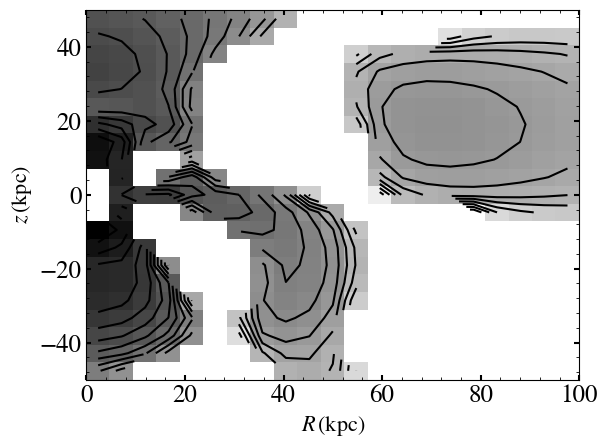

In [46]:
import astropy.units as u
pot.plotDensity(rmax=100 * u.kpc, zmin = -50 * u.kpc, zmax=50 * u.kpc,  phi=np.pi/2, log=True)

## SCF density vs. particle histogram (y–z slice)

Recreate the $y$–$z$ slice plot, but show the density reconstructed from the SCF
expansion (`pot`) instead of the particle-count difference.

- **Left:** SCF density $\rho_{\rm SCF}$, averaged through the same $x$-slab used for the histogram (white = regions where the truncated expansion rings negative).
- **Middle:** the particle 2D density histogram in the same slab.
- **Right:** the histogram with SCF density contours overlaid.

The SCF is expanded about the coordinate origin while the halo center has recoiled, so the reconstruction is pulled toward the origin and the contours can sit offset from the displaced particle peak. The spherically-averaged SCF profile still matches the particles to within a factor of ~2 inside ~100 kpc.

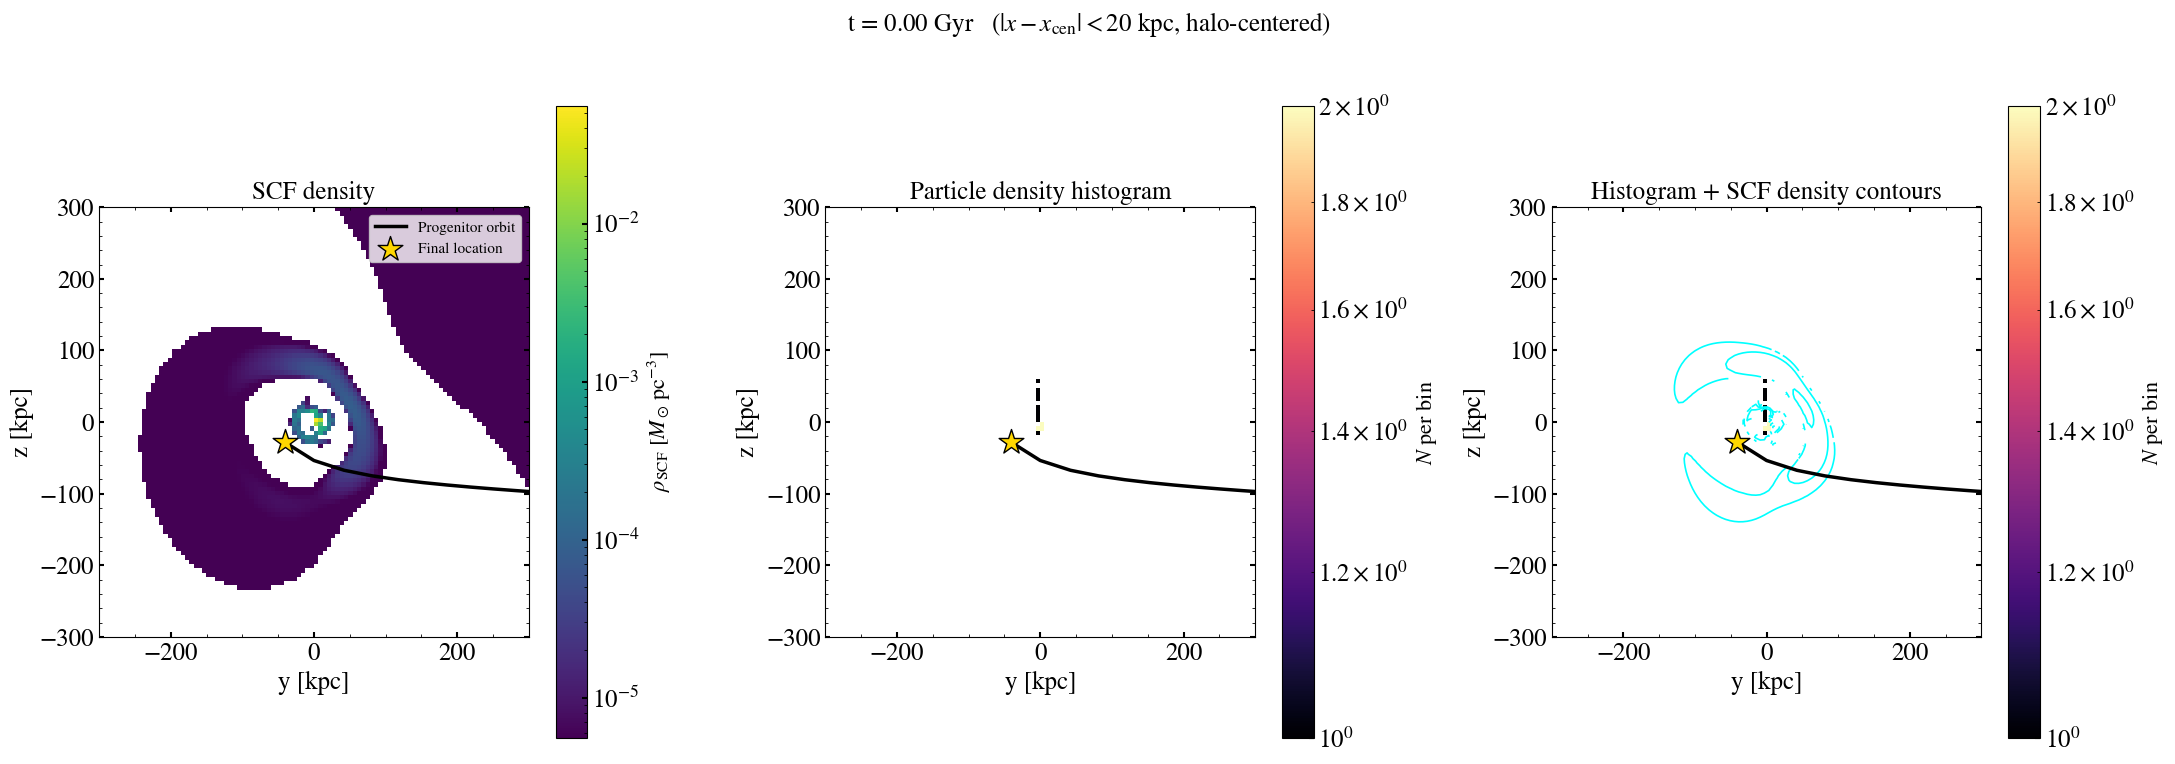

In [40]:
from matplotlib.colors import LogNorm
import astropy.units as u

filename_ext = ''

# satdf = pd.read_csv('results/lmc_particle_anisotropic/sat_trajectory.csv')
o_lmc_x = np.load(path_to_results + 'o_lmc_x'+filename_ext+'.npy')
o_lmc_y = np.load(path_to_results + 'o_lmc_y'+filename_ext+'.npy')
o_lmc_z = np.load(path_to_results + 'o_lmc_z'+filename_ext+'.npy')

# ----- slice / grid settings (mirror the original delta-N plot) -----
t_final = 0.0                # snapshot the SCF (`pot`) and `center` were built from
slice_halfwidth = 20.0       # kpc; |x_centered| < slice_halfwidth
bins = 100
extent = (-300, 300, -300, 300)
yedges = np.linspace(extent[0], extent[1], bins + 1)
zedges = np.linspace(extent[2], extent[3], bins + 1)
yc = 0.5 * (yedges[:-1] + yedges[1:])
zc = 0.5 * (zedges[:-1] + zedges[1:])

# Work in the recentered frame (`center` from the cell above) so the SCF density
# and the particle histogram share the same origin = halo density center.
\
Psnap = np.vstack([x_full[-1], y_full[-1], z_full[-1]]).T - center
sl = np.abs(Psnap[:, 0]) < slice_halfwidth        # x-slab around the halo center
H, _, _ = np.histogram2d(Psnap[sl, 1], Psnap[sl, 2], bins=[yedges, zedges])

# SCF density (Msun/pc^3) averaged through the same x-slab
Y, Z = np.meshgrid(yc, zc)                       # shape (z, y)
xplanes = np.linspace(-slice_halfwidth, slice_halfwidth, 5)
dens = np.zeros_like(Y)
for xv in xplanes:
    R = np.sqrt(xv**2 + Y**2)
    phi = np.arctan2(Y, np.full_like(Y, xv))
    dens += np.array(pot.dens(R.ravel() * u.kpc, Z.ravel() * u.kpc,
                              phi.ravel())).reshape(Y.shape)
dens /= len(xplanes)

dmax = np.nanmax(dens)
dens_pos = np.where(dens > 0, dens, np.nan)       # mask negative ringing (rho < 0)
# log-spaced levels over ~4 decades so contours reach the outskirts, not just the core.
# (They still stop where the SCF rings negative -- there is no positive rho to trace.)
levels = dmax * np.logspace(-4, -0.2, 8)

# progenitor (satellite) orbit up to t_final, in the same recentered frame
sy = o_lmc_y
sz = o_lmc_z

def _overlay(ax):
    ax.plot(sy, sz, c='k', lw=2.5, label='Progenitor orbit')
    ax.scatter(sy[-1], sz[-1], s=350, marker='*', color='gold',
               edgecolor='k', zorder=5, label='Final location')
    ax.set_xlim(extent[:2]); ax.set_ylim(extent[2:])
    ax.set_xlabel('y [kpc]', fontsize=18); ax.set_ylabel('z [kpc]', fontsize=18)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))

# Panel 1: SCF density
im0 = axes[0].imshow(dens_pos, origin='lower', extent=extent,
                     norm=LogNorm(vmin=dmax * 1e-4, vmax=dmax), cmap='viridis')
axes[0].set_title('SCF density', fontsize=18)
fig.colorbar(im0, ax=axes[0], label=r'$\rho_{\rm SCF}$ [$M_\odot\,{\rm pc}^{-3}$]')
_overlay(axes[0]); axes[0].legend(loc='upper right', fontsize=11)

# Panel 2: particle density histogram
im1 = axes[1].imshow(H.T, origin='lower', extent=extent,
                     norm=LogNorm(vmin=1, vmax=H.max()), cmap='magma')
axes[1].set_title('Particle density histogram', fontsize=18)
fig.colorbar(im1, ax=axes[1], label=r'$N$ per bin')
_overlay(axes[1])

# Panel 3: histogram + SCF density contours
im2 = axes[2].imshow(H.T, origin='lower', extent=extent,
                     norm=LogNorm(vmin=1, vmax=H.max()), cmap='magma')
axes[2].contour(yc, zc, dens_pos, levels=levels, colors='cyan', linewidths=1.2)
axes[2].set_title('Histogram + SCF density contours', fontsize=18)
fig.colorbar(im2, ax=axes[2], label=r'$N$ per bin')
_overlay(axes[2])

fig.suptitle(f't = {t_final:.2f} Gyr   '
             rf'($|x - x_{{\rm cen}}| < {slice_halfwidth:.0f}$ kpc, halo-centered)',
             fontsize=18, y=1.02)
plt.tight_layout()
#plt.savefig('02c_scf_density_yz_slice.png', dpi=200, bbox_inches='tight')
plt.show()

## Does the SCF expansion recover the density *perturbation*?

Fit the SCF to the **initial** ($t=-3$) and **final** ($t=0$) snapshots separately —
each recentered to its own median so the bulk reflex shift is removed — and difference
the reconstructed densities to get $\Delta\rho_{\rm SCF}$. Compare against the particle
count contrast $\Delta N$ (the original ΔN plot), and overlay the SCF contrast contours.

**Picking N, L:** coefficient fitting is essentially free here (<0.1 s for 200k particles);
the cost is the density-grid evaluation, which scales with the number of angular terms
($\propto L^2$), *not* with N. The halo response is dominated by low multipoles
(dipole $l=1$, quadrupole $l=2$), so a modest $L$ captures the wake while keeping
evaluation fast. **N = 8, L = 6** is a good balance (~7 s per density grid, ~25 s for the
full figure). Raising L is what slows it down; raising N is cheap, so bump N first if you
want more radial detail. (Red solid contours = overdensity, blue dashed = underdensity.)

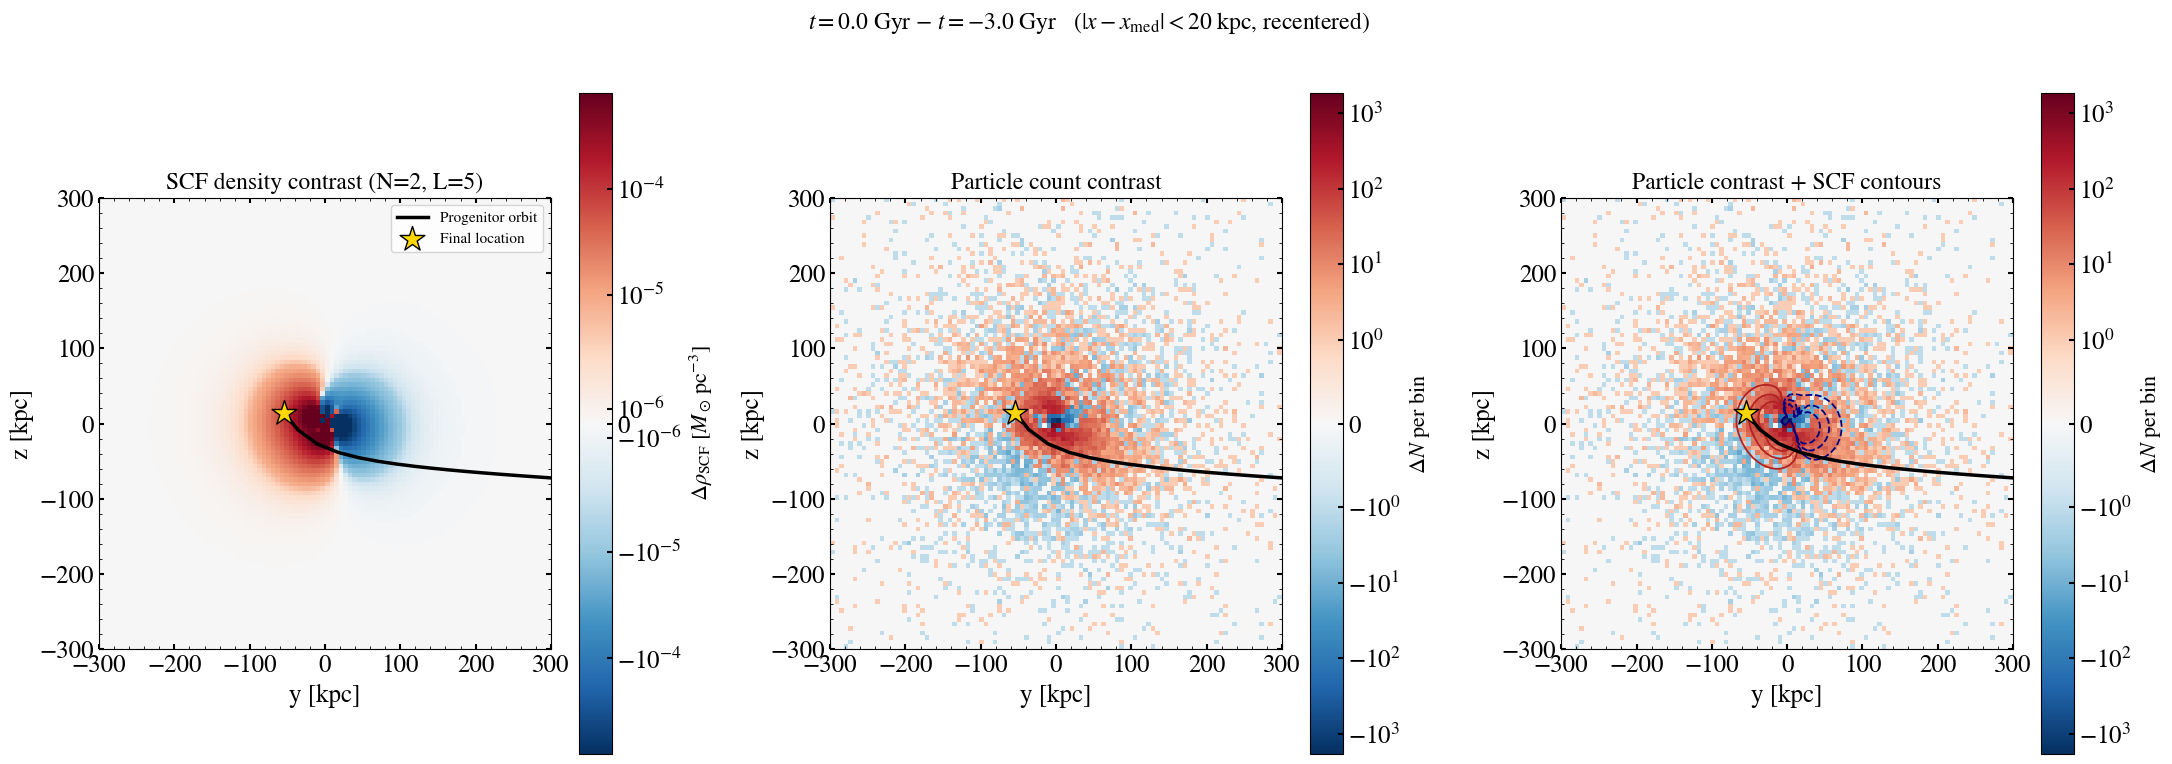

In [9]:
from matplotlib.colors import SymLogNorm
import astropy.units as u

# ---- SCF settings (see note above): low-L is fast and captures the wake ----
N_scf, L_scf = 2, 5
t_init, t_final = -3.0, 0.0
slice_halfwidth = 20.0
bins = 100
extent = (-300, 300, -300, 300)
yedges = np.linspace(extent[0], extent[1], bins + 1)
zedges = np.linspace(extent[2], extent[3], bins + 1)
yc = 0.5 * (yedges[:-1] + yedges[1:]); zc = 0.5 * (zedges[:-1] + zedges[1:])

def recentered(t):
    """Particles at time t, recentered to their median (removes bulk reflex shift)."""
    d = halo_df[halo_df['time'] == t]
    p = np.vstack([d['x'], d['y'], d['z']]).T
    return p - np.median(p, axis=0)

def scf_pot(p):
    Ac, As = scf_compute_coeffs_nbody(p / ro, N=N_scf, L=L_scf)
    pot = SCFPotential(Acos=Ac, Asin=As); pot.turn_physical_on(ro=ro)
    return pot

def slab_density(pot):
    """SCF density [Msun/pc^3] averaged through the |x| < slice_halfwidth slab."""
    Y, Z = np.meshgrid(yc, zc)
    acc = np.zeros_like(Y)
    xplanes = np.linspace(-slice_halfwidth, slice_halfwidth, 3)
    for xv in xplanes:
        R = np.sqrt(xv**2 + Y**2); phi = np.arctan2(Y, np.full_like(Y, xv))
        acc += np.array(pot.dens(R.ravel() * u.kpc, Z.ravel() * u.kpc,
                                 phi.ravel())).reshape(Y.shape)
    return acc / len(xplanes)

def hist_slab(p):
    sl = np.abs(p[:, 0]) < slice_halfwidth
    H, _, _ = np.histogram2d(p[sl, 1], p[sl, 2], bins=[yedges, zedges])
    return H

p0, pN = recentered(t_init), recentered(t_final)
dRho = slab_density(scf_pot(pN)) - slab_density(scf_pot(p0))   # SCF contrast
dH = hist_slab(pN) - hist_slab(p0)                             # particle contrast

# diverging norms (match the original SymLogNorm ΔN style)
hr_d = np.nanpercentile(np.abs(dRho), 99.5)
norm_d = SymLogNorm(linthresh=hr_d * 1e-2, vmin=-hr_d, vmax=hr_d, base=10)
hr_h = max(np.abs(dH).max(), 1.0)
norm_h = SymLogNorm(linthresh=1, vmin=-hr_h, vmax=hr_h, base=10)
cmap = plt.get_cmap('RdBu_r'); cmap.set_bad('k')

pos_lv = hr_d * np.array([0.05, 0.15, 0.4])
neg_lv = -pos_lv[::-1]

# progenitor orbit, recentered to the final-snapshot halo median
satdf = pd.read_csv('results/lmc_particle_anisotropic/sat_trajectory.csv')
med_f = np.median(np.vstack([halo_df[halo_df['time'] == t_final]['x'],
                             halo_df[halo_df['time'] == t_final]['y'],
                             halo_df[halo_df['time'] == t_final]['z']]).T, axis=0)
sat = satdf[satdf['time'] <= t_final]
sy = sat['y'].values - med_f[1]; sz = sat['z'].values - med_f[2]

def _overlay(ax):
    ax.plot(sy, sz, c='k', lw=2.5, label='Progenitor orbit')
    ax.scatter(sy[-1], sz[-1], s=350, marker='*', color='gold',
               edgecolor='k', zorder=5, label='Final location')
    ax.set_xlim(extent[:2]); ax.set_ylim(extent[2:])
    ax.set_xlabel('y [kpc]', fontsize=18); ax.set_ylabel('z [kpc]', fontsize=18)
    ax.set_aspect('equal')

fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))

im0 = axes[0].imshow(dRho, origin='lower', extent=extent, norm=norm_d, cmap=cmap)
axes[0].set_title(f'SCF density contrast (N={N_scf}, L={L_scf})', fontsize=17)
fig.colorbar(im0, ax=axes[0], label=r'$\Delta\rho_{\rm SCF}$ [$M_\odot\,{\rm pc}^{-3}$]')
_overlay(axes[0]); axes[0].legend(loc='upper right', fontsize=11)

im1 = axes[1].imshow(dH.T, origin='lower', extent=extent, norm=norm_h, cmap=cmap)
axes[1].set_title('Particle count contrast', fontsize=17)
fig.colorbar(im1, ax=axes[1], label=r'$\Delta N$ per bin')
_overlay(axes[1])

im2 = axes[2].imshow(dH.T, origin='lower', extent=extent, norm=norm_h, cmap=cmap)
axes[2].contour(yc, zc, dRho, levels=pos_lv, colors='firebrick', linewidths=1.3)
axes[2].contour(yc, zc, dRho, levels=neg_lv, colors='navy', linewidths=1.3,
                linestyles='--')
axes[2].set_title('Particle contrast + SCF contours', fontsize=17)
fig.colorbar(im2, ax=axes[2], label=r'$\Delta N$ per bin')
_overlay(axes[2])

fig.suptitle(rf'$t={t_final:.1f}$ Gyr $-$ $t={t_init:.1f}$ Gyr   '
             rf'($|x-x_{{\rm med}}|<{slice_halfwidth:.0f}$ kpc, recentered)',
             fontsize=17, y=1.02)
plt.tight_layout()
#plt.savefig('02d_scf_density_contrast.png', dpi=200, bbox_inches='tight')
plt.show()

# Gaussian Kernel

In [17]:
import numpy as np
from scipy.stats import gaussian_kde


# # scipy wants (ndim, N)
# kde = gaussian_kde(pos.T)
# kde_ini = gaussian_kde(pos_ini.T)


In [24]:
pos

array([[ 5.72940681e+01,  3.44145968e+00,  1.20358539e+02],
       [ 4.80889806e+01,  2.00187012e+00,  1.07586132e+02],
       [ 4.00413777e+01,  8.80429367e-01,  9.56248996e+01],
       [ 3.29871969e+01,  2.26625599e-02,  8.44016194e+01],
       [ 2.68045381e+01, -6.12008978e-01,  7.38589144e+01],
       [ 2.14003610e+01, -1.05509286e+00,  6.39514647e+01],
       [ 1.67023116e+01, -1.33204199e+00,  5.46434672e+01],
       [ 1.26534945e+01, -1.46429787e+00,  4.59069489e+01],
       [ 9.20904799e+00, -1.47081624e+00,  3.77207028e+01],
       [ 6.33389250e+00, -1.36936049e+00,  3.00697246e+01],
       [ 4.00129971e+00, -1.17778383e+00,  2.29451136e+01],
       [ 2.19208991e+00, -9.15524535e-01,  1.63444897e+01],
       [ 8.94372616e-01, -6.05608932e-01,  1.02730953e+01],
       [ 1.03833053e-01, -2.77619905e-01,  4.74596576e+00],
       [-1.75328012e-01,  2.75879306e-02, -2.07985584e-01],
       [ 7.14949587e-02,  2.50031974e-01, -4.53798018e+00],
       [ 8.72917820e-01,  2.97141047e-01

In [18]:
mask = np.abs(pos[:,0]) < 20
yz = pos[mask,1:3]
kde = gaussian_kde(yz.T)

mask_ini = np.abs(pos_ini[:,0]) < 20
yz_ini = pos_ini[mask_ini,1:3]
kde_ini = gaussian_kde(yz_ini.T)

In [28]:
y = np.linspace(-200, 200, 50)
z = np.linspace(-200, 200, 50)
Y, Z = np.meshgrid(y, z)

points = np.vstack([Y.ravel(), Z.ravel()])
Sigma = kde(points).reshape(Y.shape)
Sigma_ini = kde_ini(points).reshape(Y.shape)

In [29]:
Sigma

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(50, 50))

Text(0, 0.5, 'z')

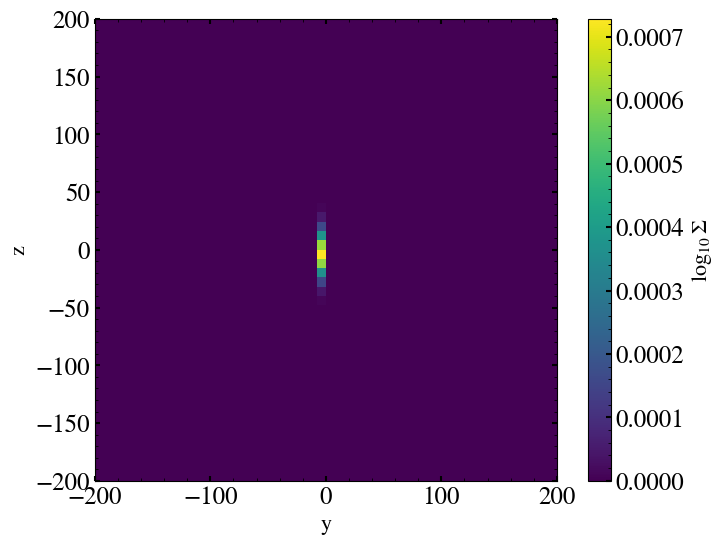

In [30]:
plt.figure(figsize=(8, 6))

plt.imshow(
    Sigma,
    origin='lower',
    extent=[y.min(), y.max(), z.min(), z.max()],
    aspect='equal'
)

plt.colorbar(label=r'$\log_{10}\Sigma$')
plt.xlabel('y')
plt.ylabel('z')

Text(0, 0.5, 'z')

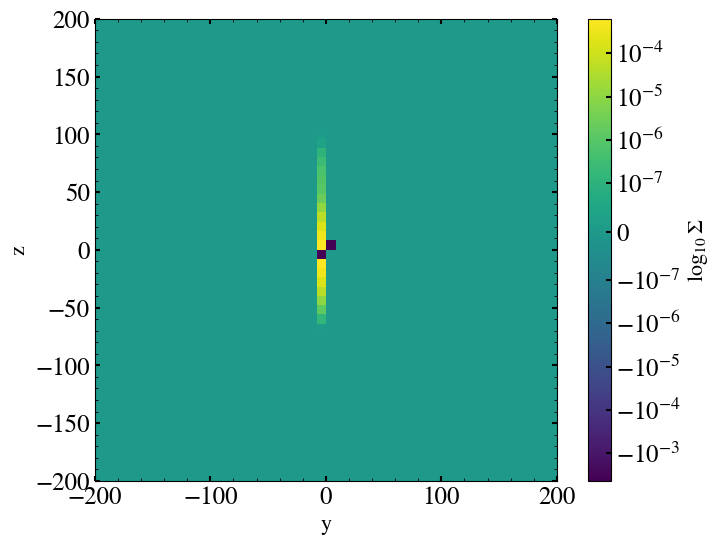

In [12]:
from matplotlib.colors import SymLogNorm
plt.figure(figsize=(8, 6))
plt.imshow(
    Sigma - Sigma_ini,
    origin='lower',
    extent=[y.min(), y.max(), z.min(), z.max()],
    aspect='equal',
    norm=SymLogNorm(
        linthresh=1e-7,  # linear region around zero
        linscale=1.0,
        vmin=(Sigma - Sigma_ini).min(),
        vmax=(Sigma - Sigma_ini).max()
    )
)

plt.colorbar(label=r'$\log_{10}\Sigma$')
plt.xlabel('y')
plt.ylabel('z')

In [14]:
print(pos)
pos.shape

[[ 5.72940681e+01  3.44145968e+00  1.20358539e+02]
 [ 4.80889806e+01  2.00187012e+00  1.07586132e+02]
 [ 4.00413777e+01  8.80429367e-01  9.56248996e+01]
 [ 3.29871969e+01  2.26625599e-02  8.44016194e+01]
 [ 2.68045381e+01 -6.12008978e-01  7.38589144e+01]
 [ 2.14003610e+01 -1.05509286e+00  6.39514647e+01]
 [ 1.67023116e+01 -1.33204199e+00  5.46434672e+01]
 [ 1.26534945e+01 -1.46429787e+00  4.59069489e+01]
 [ 9.20904799e+00 -1.47081624e+00  3.77207028e+01]
 [ 6.33389250e+00 -1.36936049e+00  3.00697246e+01]
 [ 4.00129971e+00 -1.17778383e+00  2.29451136e+01]
 [ 2.19208991e+00 -9.15524535e-01  1.63444897e+01]
 [ 8.94372616e-01 -6.05608932e-01  1.02730953e+01]
 [ 1.03833053e-01 -2.77619905e-01  4.74596576e+00]
 [-1.75328012e-01  2.75879306e-02 -2.07985584e-01]
 [ 7.14949587e-02  2.50031974e-01 -4.53798018e+00]
 [ 8.72917820e-01  2.97141047e-01 -8.15424615e+00]
 [ 2.27905453e+00  2.13035294e-02 -1.08858918e+01]
 [ 4.37910498e+00 -8.04787178e-01 -1.23584475e+01]
 [ 7.33467281e+00 -2.35647100e+

(21, 3)

# Setting Up Multipole Expansion

In [ ]:
from galpy.util.coords import cyl_to_rect

def dens_fn(R, phi, z, dens):
    pos = np.array(cyl_to_rect(R, phi, Z))
    return dens(pos.T).T

from functools import partial
pert_dens = partial(dens_fn, dens=kde)

In [ ]:
from galpy.potential import MultipoleExpansionPotential

pot = MultipoleExpansionPotential.from_density(pert_dens)

AttributeError: 'tuple' object has no attribute 'T'